In [37]:
import pandas as pd
import numpy as np
db = pd.read_csv("Salary_dataset.csv")

In [38]:
#look dataset
db.head(5)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [39]:
#drop indexing column
db.drop(columns='Unnamed: 0', inplace = True)

In [40]:
#change colume name
db.rename(columns={'YearsExperience': 'Experience'}, inplace=True)
db.head()

,Experience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [41]:
#check is there any missing value in my dataset
db.isnull().sum()

Experience    0
Salary        0
dtype: int64

In [42]:
#dataset stuctural overview
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  30 non-null     float64
 1   Salary      30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [43]:
#find how many rows and columns in the Dataframe
db.shape

(30, 2)

In [44]:
#statistical overview about dataset
db.describe()

,Experience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


<Axes: xlabel='Experience', ylabel='Salary'>

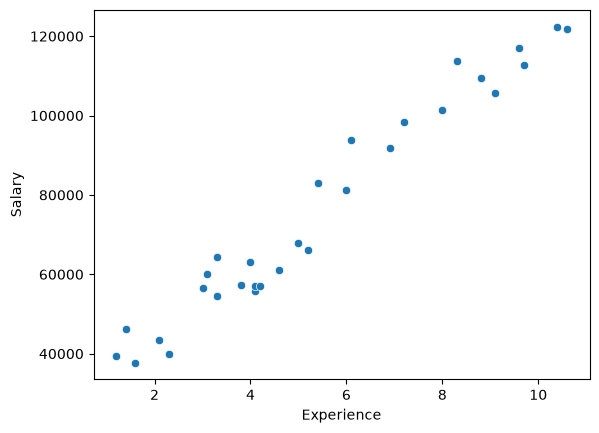

In [45]:
#visualize our dataset
import seaborn as sns
sns.scatterplot(x='Experience', y='Salary', data=db)

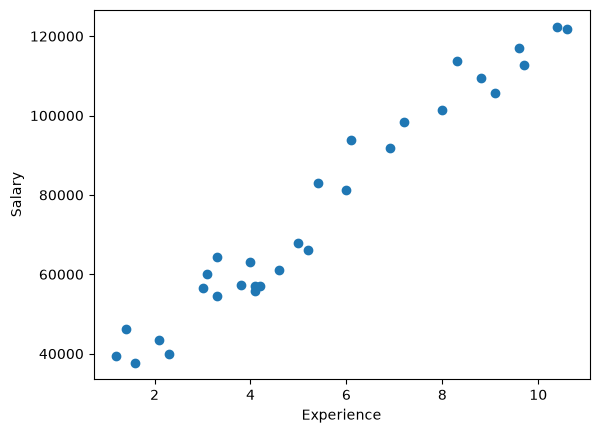

In [46]:
#ploat graph using Matploat lib
import matplotlib.pyplot as plt
plt.scatter(db['Experience'],db['Salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [47]:
#split input column
x = db.iloc[:,0].values.reshape(-1,1)

In [48]:
#split Output column
y = db.iloc[:,-1].values.reshape(-1,1)

In [49]:
#step 2 split input or output column using sklearn libaary
from sklearn.model_selection import train_test_split
#inside sklearn libaray there is model_selection module inside this module we use tarin_test_split
#method for spliting into input or output
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state =1)

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
#creating object of LinearRegression class
simple_lr = LinearRegression()
#train model
simple_lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[9202.23]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[25130.35]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[13.54]


In [52]:
print('X test value:')
print(x_test)
print()
print('Y test value:')
print(y_test)

X test value:
[[5.4]
 [7.2]
 [4. ]
 [6.1]
 [4.6]
 [6.9]
 [9.6]
 [2.1]
 [8.8]]

Y test value:
[[ 83089.]
 [ 98274.]
 [ 63219.]
 [ 93941.]
 [ 61112.]
 [ 91739.]
 [116970.]
 [ 43526.]
 [109432.]]


In [53]:
#in line vale of m(slope) and b(intersept in y)
print('vale of m(slope):',simple_lr.coef_)
print('vale of b (intersept):',simple_lr.intercept_)

vale of m(slope): [[9202.23359825]]
vale of b (intersept): [25130.35435562]


In [54]:
simple_lr.predict([[7.2]])

array([[91386.43626305]])

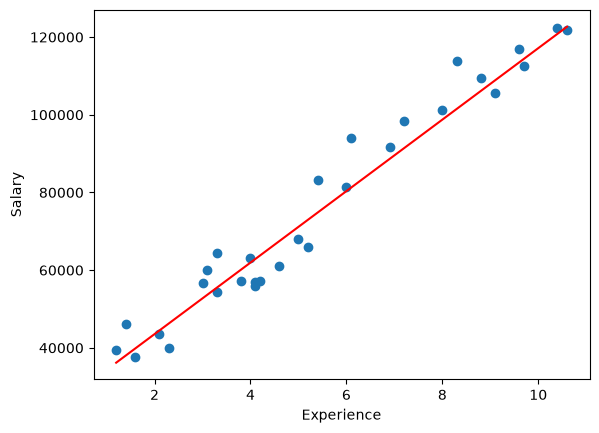

In [55]:
plt.scatter(x,y)
plt.plot(x,simple_lr.predict(x), color='red')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [56]:
#evalution
from sklearn.metrics import r2_score
r2_score(y_test,simple_lr.predict(x_test))

0.9248580247217076